# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve, PlotType
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels)

## Simulation $H=0.8$

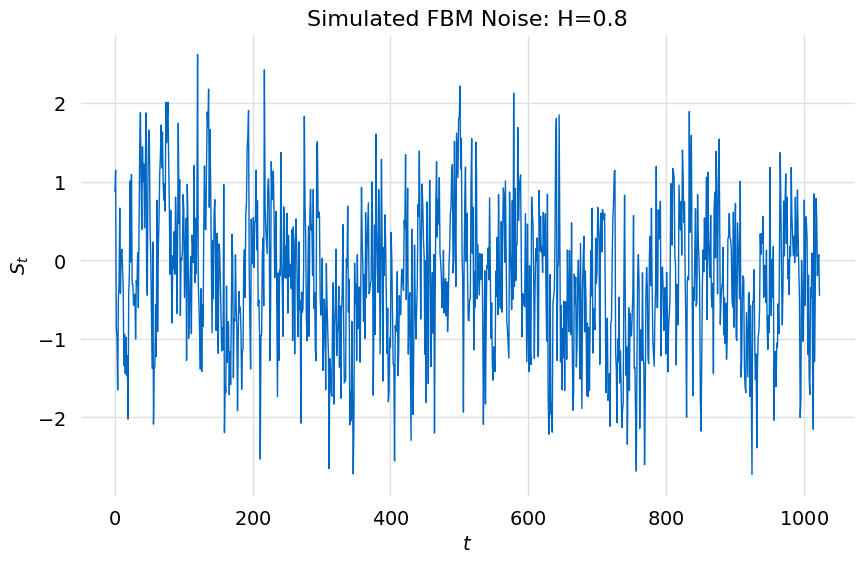

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

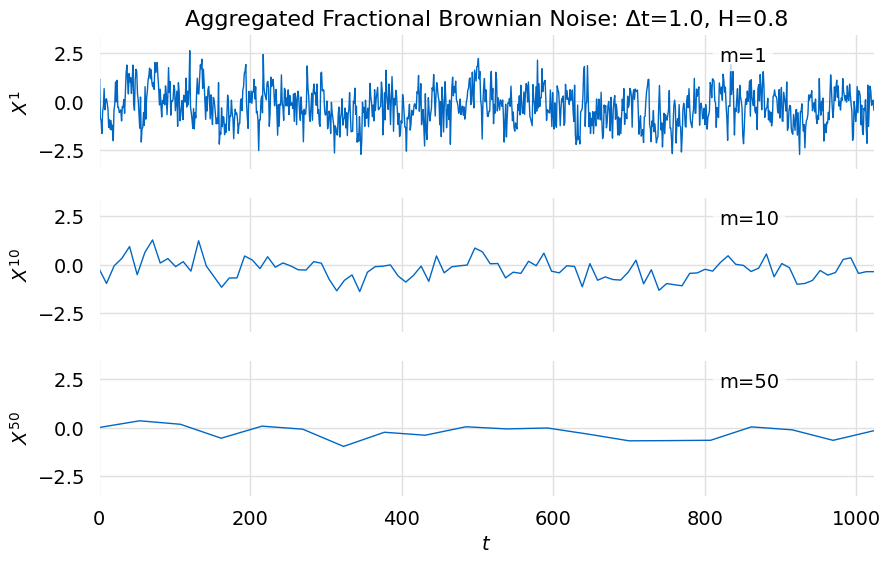

In [4]:
var_agg_comparison(t, fbm_noise, H)

In [5]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [6]:
report, results = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     6894.
Date:                Sun, 23 Jul 2023   Prob (F-statistic):           1.24e-92
Time:                        11:58:41   Log-Likelihood:                 182.34
No. Observations:                 100   AIC:                            -360.7
Df Residuals:                      98   BIC:                            -355.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0250      0.008      3.186      0.002       0.009       0.041
x1            -0.5620      0.007    -83.030      0.000      -0.575      -0.549
==============================================================================
Omnibus:                       22.227   Durbin-Watson:                   1.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.583
Skew:                          -0.966   Prob(JB):                     1.88e-08
Kurtosis:                       5.192   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -0.5619702419935184,
  'Error': 0.006768318112106386,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': 0.024959810210292307,
  'Error': 0.007835091521263668,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.9859837854868688,
 'transform': {'model': '$\\sigma^2 m^{2\\left(H-1\\right)}$',
  'param': {'Estimate': 0.7190148790032408,
   'Error': 0.003384159056053193,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 1.059155705937996,
   'Error': 0.008298581891292827,
   'Estimate Label': '$\\hat{\\sigma}^2$',
   'Error Label': '$\\sigma^2_{\\hat{\\sigma}^2}$'}}}

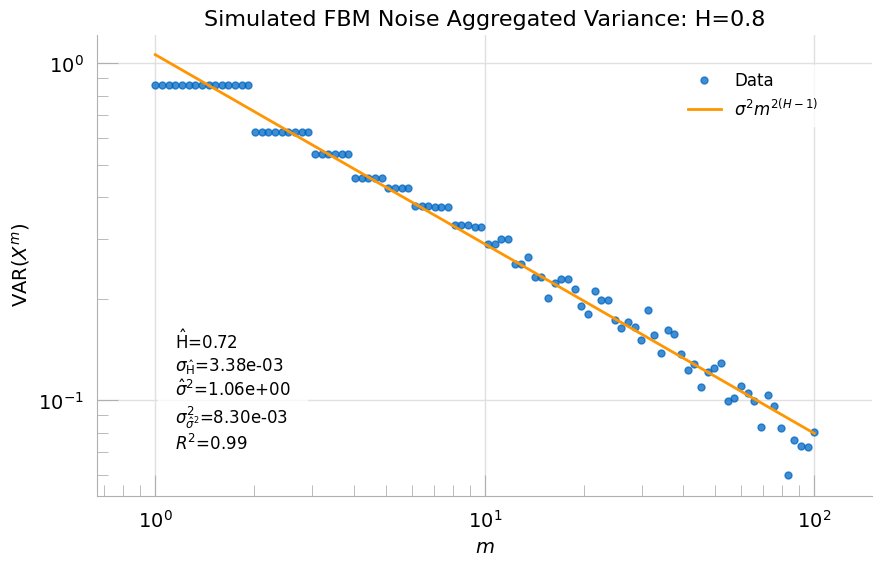

In [8]:
variance_agg(agg_var, results, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

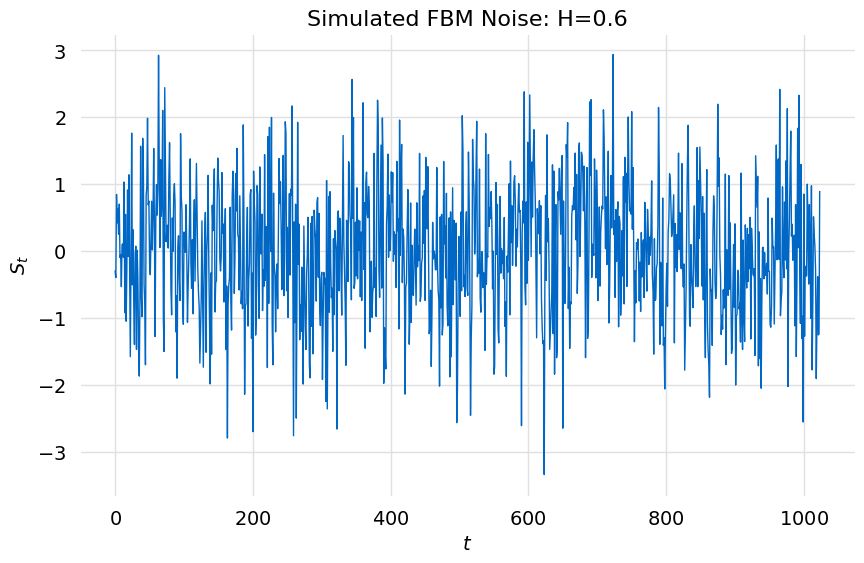

In [9]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

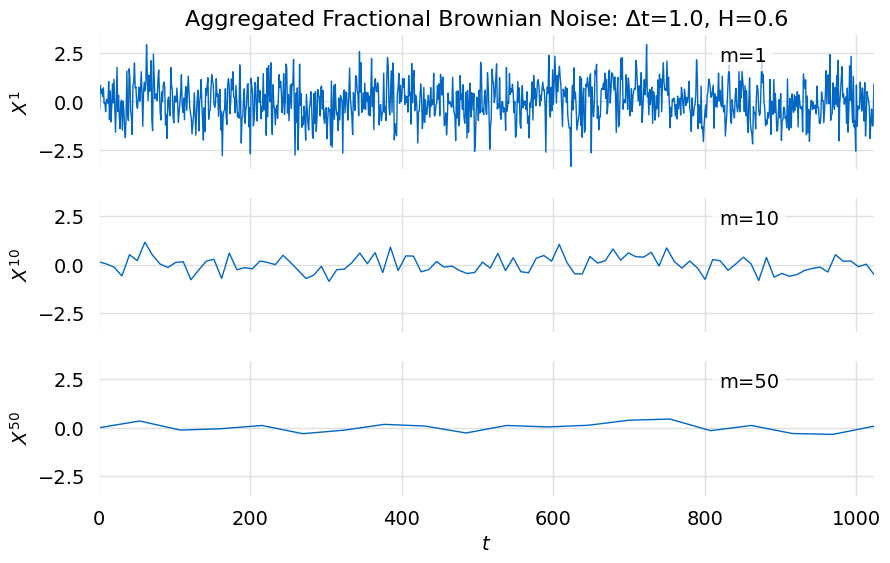

In [10]:
var_agg_comparison(t, fbm_noise, H)

In [11]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [12]:
report, results = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     4797.
Date:                Sun, 23 Jul 2023   Prob (F-statistic):           4.82e-85
Time:                        11:58:42   Log-Likelihood:                 131.32
No. Observations:                 100   AIC:                            -258.6
Df Residuals:                      98   BIC:                            -253.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0510      0.013      3.904      0.000       0.025       0.077
x1            -0.7808      0.011    -69.258      0.000      -0.803      -0.758
==============================================================================
Omnibus:                       14.650   Durbin-Watson:                   1.185
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.601
Skew:                           0.750   Prob(JB):                     9.14e-05
Kurtosis:                       4.487   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -0.7808075116639419,
  'Error': 0.011273842943192492,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': 0.050950398131590816,
  'Error': 0.01305074463008297,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.9799784093236216,
 'transform': {'model': '$\\sigma^2 m^{2\\left(H-1\\right)}$',
  'param': {'Estimate': 0.609596244168029,
   'Error': 0.005636921471596246,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 1.1244765373303904,
   'Error': 0.014675256131218886,
   'Estimate Label': '$\\hat{\\sigma}^2$',
   'Error Label': '$\\sigma^2_{\\hat{\\sigma}^2}$'}}}

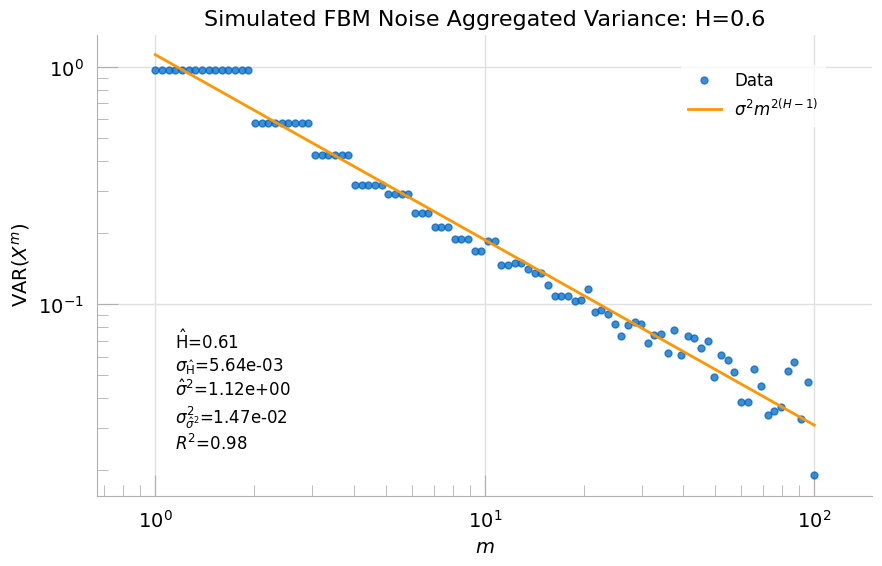

In [14]:
variance_agg(agg_var, results, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

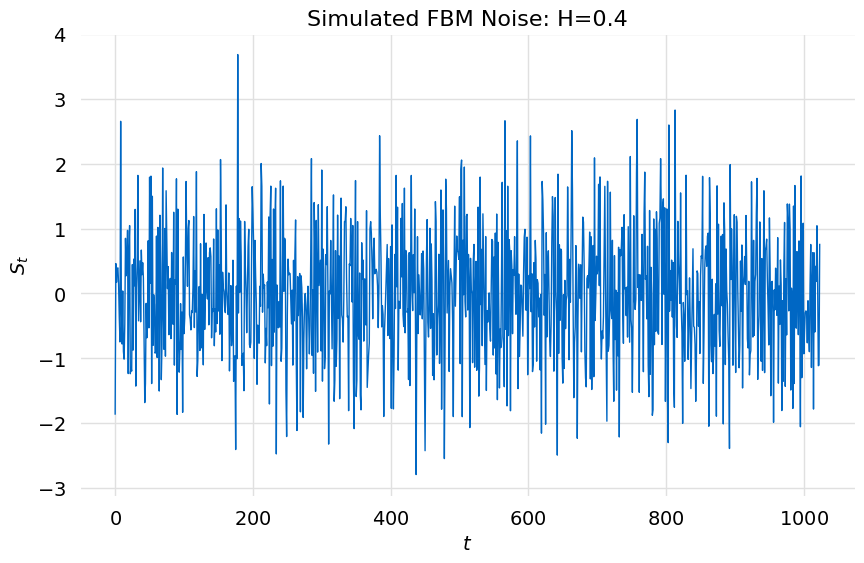

In [15]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

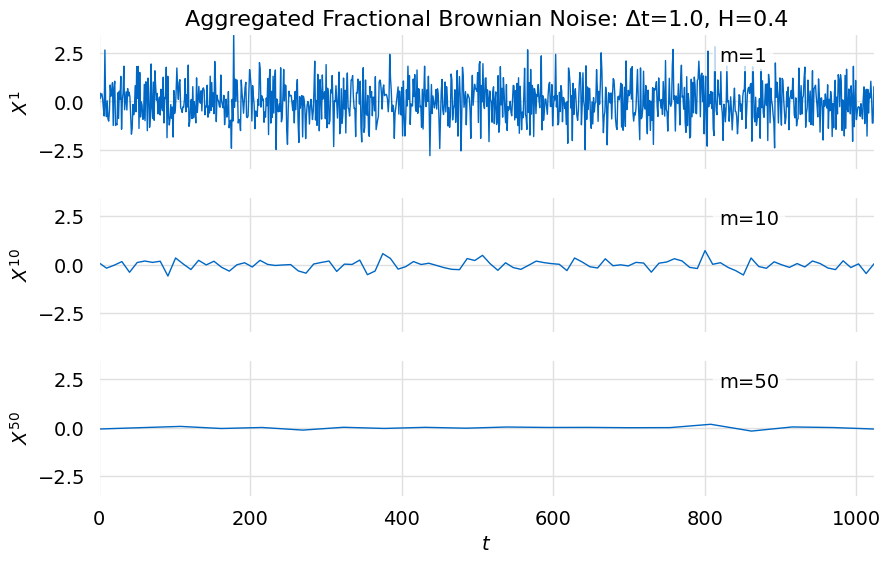

In [16]:
var_agg_comparison(t, fbm_noise, H)

In [17]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [18]:
report, results = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     6253.
Date:                Sun, 23 Jul 2023   Prob (F-statistic):           1.38e-90
Time:                        11:58:43   Log-Likelihood:                 87.198
No. Observations:                 100   AIC:                            -170.4
Df Residuals:                      98   BIC:                            -165.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1863      0.020      9.182      0.000       0.146       0.227
x1            -1.3858      0.018    -79.075      0.000      -1.421      -1.351
==============================================================================
Omnibus:                       12.667   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               23.385
Skew:                          -0.471   Prob(JB):                     8.36e-06
Kurtosis:                       5.174   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -1.385840948174517,
  'Error': 0.01752561547846968,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': 0.18627647486295112,
  'Error': 0.020287876392020083,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.9845690720461863,
 'transform': {'model': '$\\sigma^2 m^{2\\left(H-1\\right)}$',
  'param': {'Estimate': 0.30707952591274146,
   'Error': 0.00876280773923484,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 1.5355942415882,
   'Error': 0.031153946161639228,
   'Estimate Label': '$\\hat{\\sigma}^2$',
   'Error Label': '$\\sigma^2_{\\hat{\\sigma}^2}$'}}}

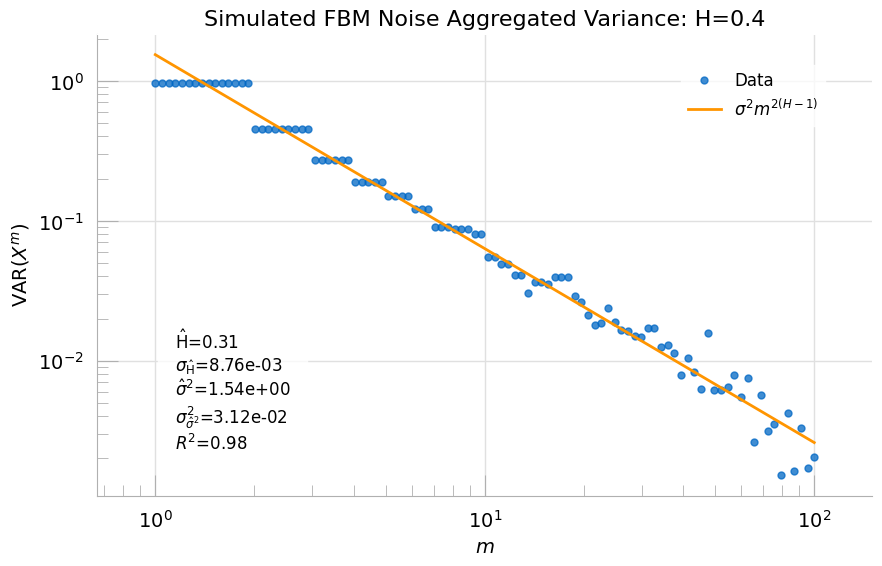

In [20]:
variance_agg(agg_var, results, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

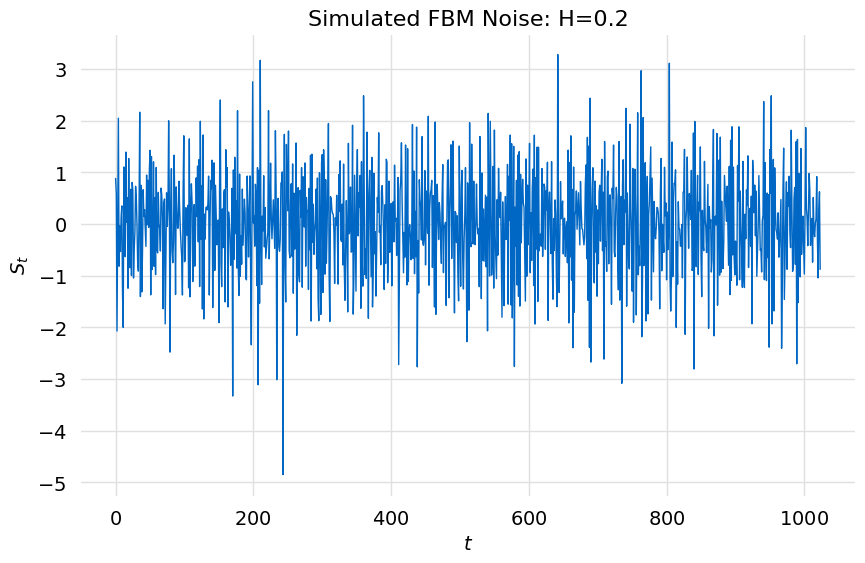

In [21]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

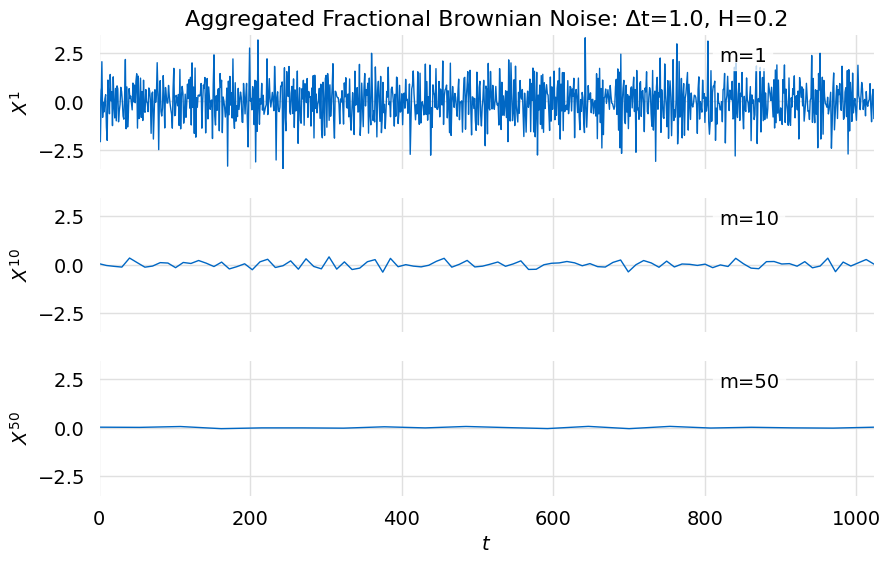

In [22]:
var_agg_comparison(t, fbm_noise, H)

In [23]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [24]:
report, results = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     5903.
Date:                Sun, 23 Jul 2023   Prob (F-statistic):           2.21e-89
Time:                        11:58:44   Log-Likelihood:                 59.235
No. Observations:                 100   AIC:                            -114.5
Df Residuals:                      98   BIC:                            -109.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2434      0.027      9.070      0.000       0.190       0.297
x1            -1.7810      0.023    -76.833      0.000      -1.827      -1.735
==============================================================================
Omnibus:                        3.007   Durbin-Watson:                   1.699
Prob(Omnibus):                  0.222   Jarque-Bera (JB):                2.443
Skew:                           0.251   Prob(JB):                        0.295
Kurtosis:                       3.578   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -1.7809807974748073,
  'Error': 0.02318003950847567,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': 0.2433789610191861,
  'Error': 0.026833509892296242,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.9836700300609775,
 'transform': {'model': '$\\sigma^2 m^{2\\left(H-1\\right)}$',
  'param': {'Estimate': 0.10950960126259635,
   'Error': 0.011590019754237835,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 1.7513742537075687,
   'Error': 0.04699551836197499,
   'Estimate Label': '$\\hat{\\sigma}^2$',
   'Error Label': '$\\sigma^2_{\\hat{\\sigma}^2}$'}}}

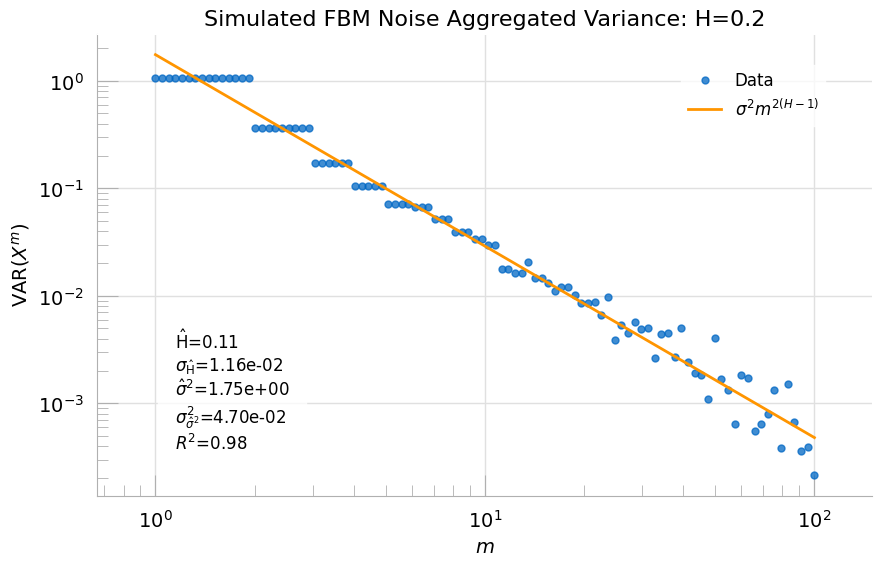

In [26]:
variance_agg(agg_var, results, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")